# Books to Scrape - Data Analysis

Exploring the 1000 books scraped from [books.toscrape.com](https://books.toscrape.com) to answer questions about pricing, ratings, stock, and category patterns.

**Source data:** `output/books.json` (produced by `scraper.py`)

**Questions to answer:**
1. What does the price distribution look like?
2. Do higher-ranked books cost more, or is rating independent of price?
3. Which categories are the largest, and which command the highest prices?
4. What's stock availability like across the catalog?
5. Are there any surprising outliers?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# setting up charts style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# showing more of wider dataframes
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Loading the data

The scraper output is saved as a JSON file, which preserves data types better than CSV files (integers stay as integers, nulls stay as nulls etc.)

In [3]:
df = pd.read_json("output/books.json")
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 1000 rows, 16 columns


,title,price_gbp,rating,in_stock,url,image_url,description,upc,product_type,price_excl_tax,price_incl_tax,tax,availability_count,num_reviews,category,scraped_at
0,A Light in the Attic,51.77,3,True,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/media/cache/2c/da/2...,It's hard to imagine a world without A Light i...,a897fe39b1053632,Books,51.77,51.77,0,22,0,Poetry,2026-04-17 16:48:42.824196+00:00
1,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,2,True,https://books.toscrape.com/catalogue/starving-...,https://books.toscrape.com/media/cache/be/f4/b...,"Since her assault, Miss Annette Chetwynd has b...",0312262ecafa5a40,Books,13.99,13.99,0,19,0,Default,2026-04-17 16:48:42.826297+00:00
2,Tipping the Velvet,53.74,1,True,https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/media/cache/26/0c/2...,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,Books,53.74,53.74,0,20,0,Historical Fiction,2026-04-17 16:48:42.824774+00:00
3,Shakespeare's Sonnets,20.66,4,True,https://books.toscrape.com/catalogue/shakespea...,https://books.toscrape.com/media/cache/10/48/1...,This book is an important and complete collect...,30a7f60cd76ca58c,Books,20.66,20.66,0,19,0,Poetry,2026-04-17 16:48:42.826474+00:00
4,Soumission,50.10,1,True,https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/media/cache/3e/ef/3...,"Dans une France assez proche de la nÃ´tre, un ...",6957f44c3847a760,Books,50.10,50.10,0,20,0,Fiction,2026-04-17 16:48:42.824953+00:00


In [4]:
# checking data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   title               1000 non-null   str                
 1   price_gbp           1000 non-null   float64            
 2   rating              1000 non-null   int64              
 3   in_stock            1000 non-null   bool               
 4   url                 1000 non-null   str                
 5   image_url           1000 non-null   str                
 6   description         998 non-null    str                
 7   upc                 1000 non-null   str                
 8   product_type        1000 non-null   str                
 9   price_excl_tax      1000 non-null   float64            
 10  price_incl_tax      1000 non-null   float64            
 11  tax                 1000 non-null   int64              
 12  availability_count  1000 non-null   int64     

In [5]:
# numeric columns summary

df.describe()

,price_gbp,rating,price_excl_tax,price_incl_tax,tax,availability_count,num_reviews
count,1000.00000,1000.000000,1000.00000,1000.00000,1000.0,1000.000000,1000.0
mean,35.07035,2.923000,35.07035,35.07035,0.0,8.585000,0.0
std,14.44669,1.434967,14.44669,14.44669,0.0,5.654622,0.0
min,10.00000,1.000000,10.00000,10.00000,0.0,1.000000,0.0
25%,22.10750,2.000000,22.10750,22.10750,0.0,3.000000,0.0
50%,35.98000,3.000000,35.98000,35.98000,0.0,7.000000,0.0
75%,47.45750,4.000000,47.45750,47.45750,0.0,14.000000,0.0
max,59.99000,5.000000,59.99000,59.99000,0.0,22.000000,0.0


## Question 1: What does the price distribution look like?

How are the book prices distributed? Are most books in a narrow band, or widely spread?

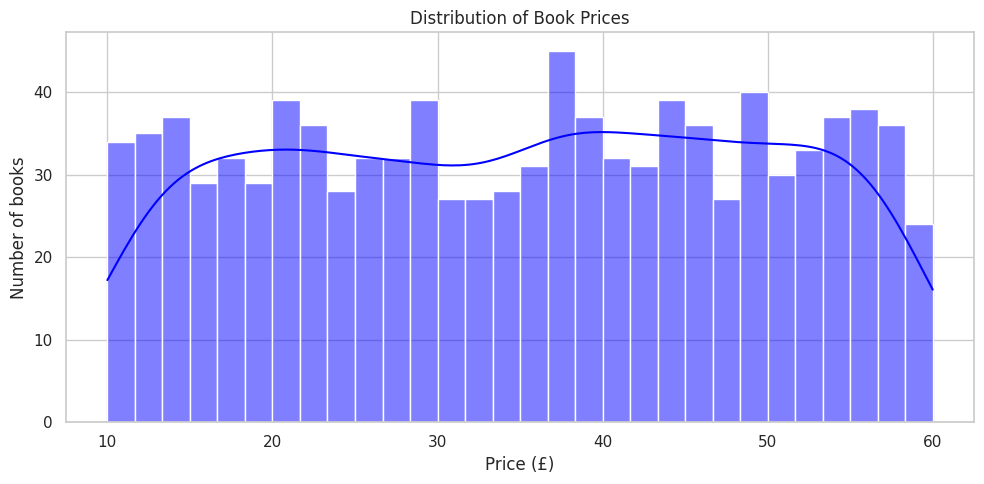

Median price: £35.98
Mean price: £35.07
Price range: £10.00 - £59.99


In [6]:
fig, ax = plt.subplots()
sns.histplot(df["price_gbp"], bins = 30, kde = True, ax = ax, color = "blue")
ax.set_title("Distribution of Book Prices")
ax.set_xlabel("Price (£)")
ax.set_ylabel("Number of books")
plt.tight_layout()
plt.show()

print(f"Median price: £{df['price_gbp'].median():.2f}")
print(f"Mean price: £{df['price_gbp'].mean():.2f}")
print(f"Price range: £{df['price_gbp'].min():.2f} - £{df['price_gbp'].max():.2f}")

## Question 2: Do higher-rating books cost more, or is rating independent of price?

Looking at the average price compared to ratings.

In [7]:
rating_stats = df.groupby("rating")["price_gbp"].agg(
    mean_price = "mean",
    median_price = "median",
    count = "count",
).round(2)
rating_stats

,mean_price,median_price,count
rating,,,
1,34.56,34.77,226
2,34.81,36.22,196
3,34.69,33.78,203
4,36.09,37.80,179
5,35.37,36.90,196


/tmp/ipykernel_1684/1473759090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x="rating", y="price_gbp", ax=ax, palette = "viridis")


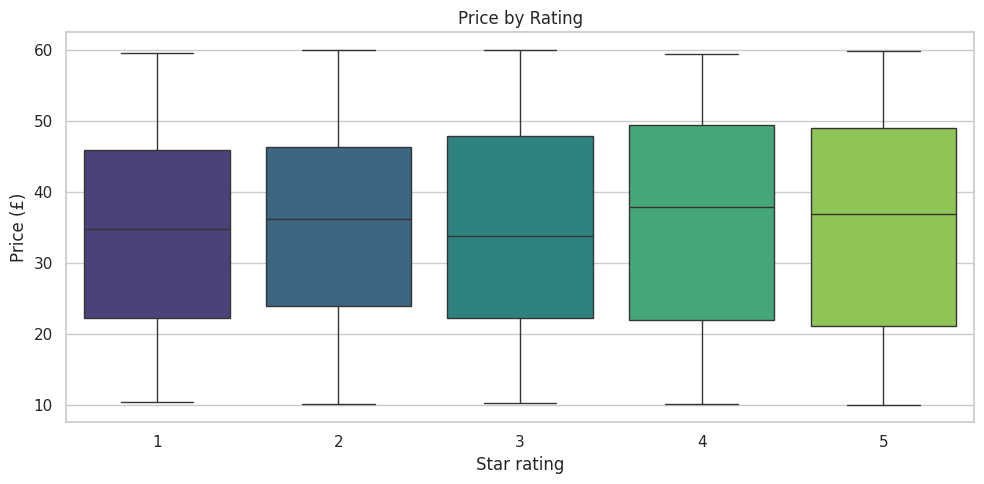

In [8]:
fig, ax = plt.subplots()
sns.boxplot(data = df, x="rating", y="price_gbp", ax=ax, palette = "viridis")
ax.set_title("Price by Rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Price (£)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1684/1505216854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="rating", y="price_gbp", ax=ax, palette="viridis")


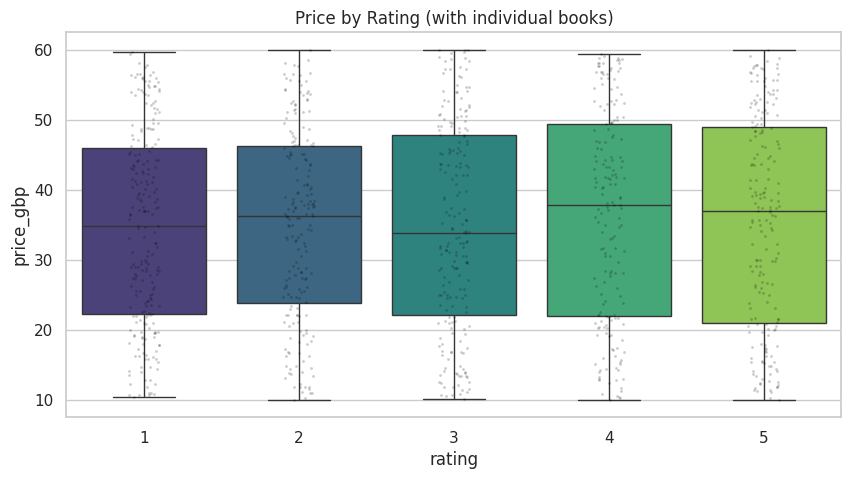

In [9]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="rating", y="price_gbp", ax=ax, palette="viridis")
sns.stripplot(data=df, x="rating", y="price_gbp", ax=ax, 
              color="black", alpha=0.2, size=2)
ax.set_title("Price by Rating (with individual books)")
plt.show()

**Finding:** On this site, price and rating are effectively independent. The average price is roughly the same across all rating bands - you don't pay more for higher-rated books.

In a real e-commerce analysis, this pattern would be worth flagging to the business: it suggests pricing isn't reflecting quality signals, or ratings aren't trusted as a quality signal by buyers.

## Question 3: Which categories are the largest, and which command the highest prices?

Which categories dominate the catalog, and which ones are "premium"?

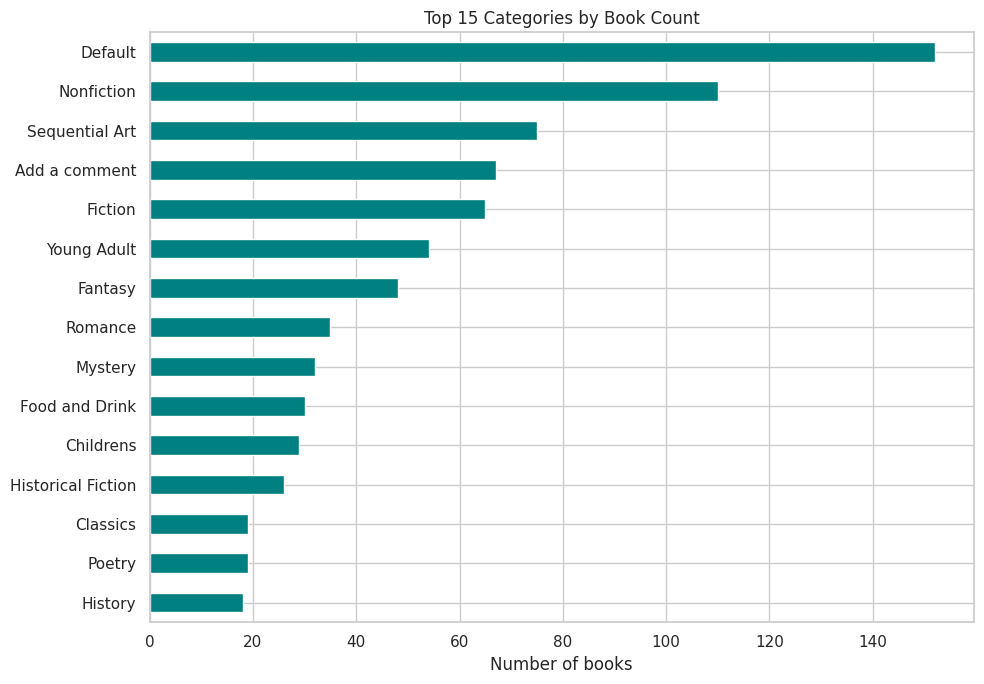

In [12]:
top_categories = (
    df["category"]
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))
top_categories.sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 15 Categories by Book Count")
ax.set_xlabel("Number of books")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [22]:
bad_category_books = df[df["category"] == "Add a comment"]
print(bad_category_books[["title", "url"]].head(3).to_string(index=False))

                                                                                                                                                 title                                                                                                                                                                                                     url
                                                                                                           The Torch Is Passed: A Harding Family Story                                                                                                          https://books.toscrape.com/catalogue/the-torch-is-passed-a-harding-family-story_945/index.html
The Mindfulness and Acceptance Workbook for Anxiety: A Guide to Breaking Free from Anxiety, Phobias, and Worry Using Acceptance and Commitment Therapy https://books.toscrape.com/catalogue/the-mindfulness-and-acceptance-workbook-for-anxiety-a-guide-to-breaking-free-from-anxiety-phobias-and-worry-us

### Data quality note

Two categories stand out as data quality issues on the source site:

- **"Default"** (152 books, ~15%) - books that weren't assigned a real category
- **"Add a comment"** (67 books, ~7%) - an odd category that appears to be a leftover from site development

Together these account for **~22% of the catalog**. The source site's own breadcrumb navigation places books in these categories, so this isn't a scraper bug, but rather an issue with the website.

For the analysis that follows, I'll work with a cleaned view that excludes these two categories.

In [23]:
# Exclude known-bad categories for the deeper analysis below
BAD_CATEGORIES = {"Default", "Add a comment"}
clean_df = df[~df["category"].isin(BAD_CATEGORIES)].copy()

print(f"Original dataset:  {len(df)} books")
print(f"Cleaned dataset:   {len(clean_df)} books ({len(clean_df)/len(df)*100:.1f}% retained)")
print(f"Excluded:          {len(df) - len(clean_df)} books from {len(BAD_CATEGORIES)} suspect categories")

Original dataset:  1000 books
Cleaned dataset:   781 books (78.1% retained)
Excluded:          219 books from 2 suspect categories


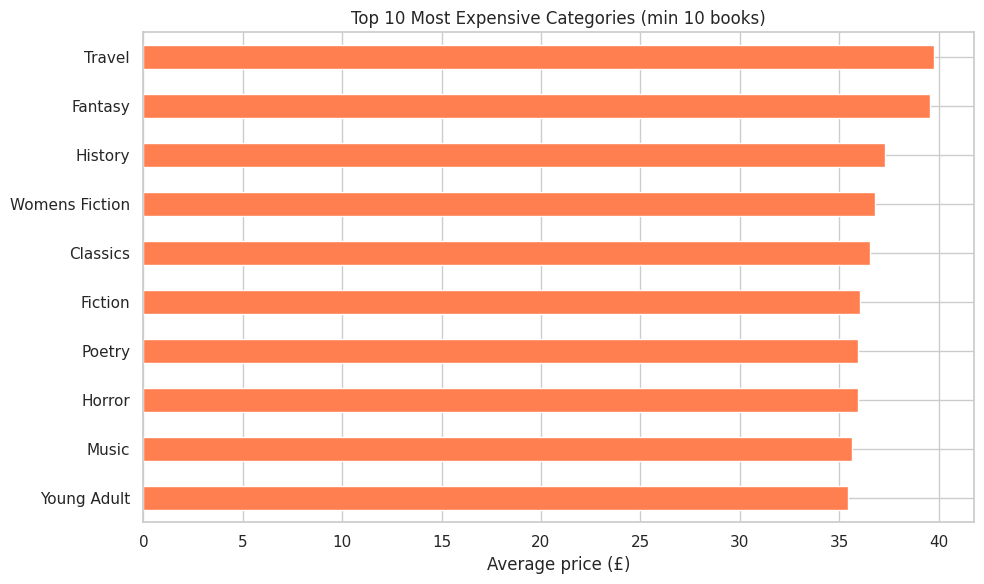

,book_count,avg_price
category,,
Young Adult,54,35.449074
Music,13,35.636923
Horror,17,35.949412
Poetry,19,35.974211
Fiction,65,36.066615
Classics,19,36.545263
Womens Fiction,17,36.791176
History,18,37.295000
Fantasy,48,39.593958


In [25]:
# Average price for categories with at least 10 books (to keep stats meaningful)
category_prices = (
    clean_df.groupby("category")
    .agg(book_count=("title", "count"), avg_price=("price_gbp", "mean"))
    .query("book_count >= 10")
    .sort_values("avg_price", ascending=False)
    .head(10)
    .sort_values("avg_price", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
category_prices["avg_price"].plot(kind="barh", ax=ax, color="coral")
ax.set_title("Top 10 Most Expensive Categories (min 10 books)")
ax.set_xlabel("Average price (£)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

category_prices

**Finding:** The priciest categories (Travel, Fantasy, History) average £37-40, while the cheapest in the top 10 (Young Adult, Music) average ~£35. The spread across well-populated categories is narrow at about £4 or roughly 12%.

In real e-commerce data, category-level price differences are typically much larger due to genuine product mix effects. The flatness here is consistent with the site's own disclaimer that prices are randomly assigned, making this more useful as a methodology demo than a source of real market insight.

**Sample size note:** Music (13 books) and a few others are right at the minimum threshold. A production analysis would use confidence intervals to quantify how reliable each category's mean is.

## Question 4: What's stock availability like across the catalog?

The scraper captures exact stock counts from detail pages. What's the overall stock picture?

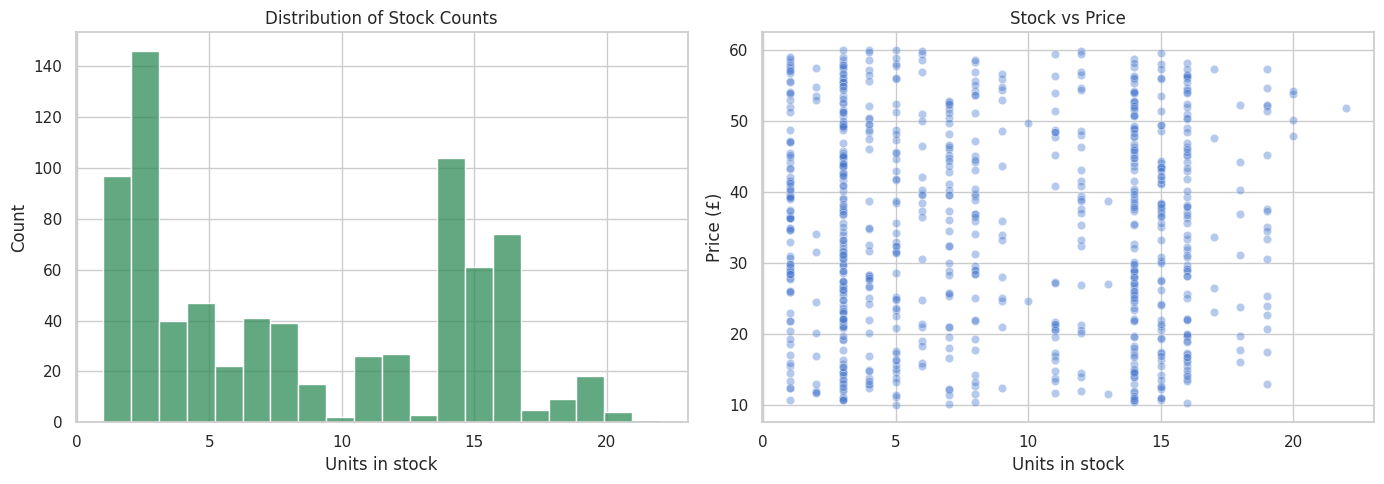

Total books:       781
Out of stock:      0
Median stock:      7 units
Total stock value: £234,956.26


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of stock counts
sns.histplot(clean_df["availability_count"], bins=20, ax=axes[0], color="seagreen")
axes[0].set_title("Distribution of Stock Counts")
axes[0].set_xlabel("Units in stock")

# Right: stock vs price scatter
sns.scatterplot(data=clean_df, x="availability_count", y="price_gbp", alpha=0.4, ax=axes[1])
axes[1].set_title("Stock vs Price")
axes[1].set_xlabel("Units in stock")
axes[1].set_ylabel("Price (£)")

plt.tight_layout()
plt.show()

print(f"Total books:       {len(clean_df)}")
print(f"Out of stock:      {(clean_df['availability_count'] == 0).sum()}")
print(f"Median stock:      {clean_df['availability_count'].median():.0f} units")
print(f"Total stock value: £{(clean_df['availability_count'] * clean_df['price_gbp']).sum():,.2f}")

**Findings:**

- **Stock distribution is bimodal**, with clear peaks at 1-3 units and 14-16 units, and a notable valley around 9-11. This likely reflects either two distinct stock management processes on the source site, or an artefact of whatever generates the fake data.
- No books are out of stock, every title has at least 1 unit available.
- **Median stock (7 units) sits in the valley between the two peaks**, making it a poor summary of typical stock levels.
- The scatter plot shows **no visible relationship between stock level and price** as prices are spread across the full £10-60 range at every stock level.
- Total catalog inventory value is approximately **£235,000** across 781 books (cleaned dataset).

A bimodal stock distribution suggests two populations mixed together, which might require separate analysis.

## Question 5: Reviews and outliers

The data shows every book has 0 reviews, in a realistic site there would be reviews.

Instead, I will look for price outliters, the least and most expensive books.

In [28]:
# Most expensive and cheapest books
most_expensive = clean_df.nlargest(5, "price_gbp")[["title", "category", "price_gbp", "rating"]]
cheapest = clean_df.nsmallest(5, "price_gbp")[["title", "category", "price_gbp", "rating"]]

print("Most expensive books:")
print(most_expensive.to_string(index=False))
print("\nCheapest books:")
print(cheapest.to_string(index=False))

Most expensive books:
                             title       category  price_gbp  rating
The Perfect Play (Play by Play #1)        Romance      59.99       3
 Last One Home (New Beginnings #1)        Fiction      59.98       3
  Civilization and Its Discontents     Psychology      59.95       2
    The Barefoot Contessa Cookbook Food and Drink      59.92       5
         The Diary of a Young Girl     Nonfiction      59.90       3

Cheapest books:
                                                      title       category  price_gbp  rating
                                 An Abundance of Katherines    Young Adult      10.00       5
                                      The Origin of Species        Science      10.01       4
                                                   Patience Sequential Art      10.16       3
                                          History of Beauty            Art      10.29       4
The Lucifer Effect: Understanding How Good People Turn Evil     Psychology   

**Observations:**
- The most expensive books cluster right at £59.99, the site's maximum price point.
- The cheapest books cluster around £10.00, the price floor.
- **Both extremes are artefacts of this site's random price generation**, bounded by hard limits, rather than meaningful outliers.

## Summary

This notebook explored 1000 books scraped from [books.toscrape.com](https://books.toscrape.com) using a standard analytical pipeline: load, validate, clean, explore, visualise, interpret.

### Key findings

**Data quality**

About 22% of the catalog had suspect categorisation. 152 books (15%) sat in a "Default" category, likely uncategorised source data. Another 67 books (7%) were labelled "Add a comment", which appears to be a leftover category on the source site rather than a real one. Both were excluded from the category-level analysis.

**Pricing patterns**

Prices range from £10 to £60, with heavy clustering at both the £59.99 ceiling and the £10.00 floor. These extremes are artefacts of the site's random price generation rather than a real premium or clearance segment.

Ratings and price turn out to be independent. The average price of 1-star books differs from 5-star books by less than £2. On a real catalog, this kind of finding would be worth raising with the business.

Categories also vary narrowly in average price. Travel and Fantasy top the list at roughly £40, and Young Adult bottoms out at around £35. A 12% spread across well-populated categories is unusually flat for a real e-commerce catalog.

**Stock patterns**

The stock distribution is bimodal, with clear peaks at 1-3 units and 14-16 units, and a distinct valley around 9-11. This is the kind of pattern that warrants investigation in real data, since it often signals two different underlying processes mixed together.

The median stock level is 7 units, but because it sits in the valley between the two peaks, it's a misleading summary of typical stock. This is a good reminder that single summary statistics can lie when the distribution isn't unimodal.

Total catalog inventory value comes to roughly £235,000 across 781 books in the cleaned dataset.

### Analytical caveats

The site openly states that prices and ratings are randomly assigned, so the lack of meaningful relationships reflects the source data rather than a failure of analysis.

Several categories have small book counts in the 10 to 20 range. Findings for these should be treated as indicative rather than statistically robust.

In real client work, reasonable next steps would be adding confidence intervals to category means, running proper hypothesis tests on the ratings-price relationship, and digging deeper into what's driving the bimodal stock distribution.

### What this demonstrates

An end-to-end data pipeline in Python:

1. Scraping via a two-stage concurrent pipeline extracting 16 fields across 1000 books (see [`scraper.py`](scraper.py))
2. Validation, including identifying and quantifying data quality issues
3. Cleaning by excluding suspect categories from downstream analysis
4. Exploration using groupby, aggregation, filtering, and method chaining
5. Visualisation with histograms, boxplots, scatter plots, bar charts, and multi-panel figures
6. Interpretation that turns numbers and charts into findings useful to a business

Combining scraping and analysis in a single repository shows the full lifecycle of extracting value from web data, which is what most real-world scraping projects actually require.